# 41. The Singular Value Decomposition

**Part 6: Eigenvalue Problems and the Singular Value Decomposition**

## Learning objectives

By the end of this lesson you will be able to:

1. State the SVD **geometrically**: every matrix maps the unit sphere to a hyperellipse.
2. Verify that claim by brute force, and say where brute force stops working.
3. Say why the SVD **always exists**, where an eigendecomposition need not.
4. Say precisely what is unique about it and what is not.
5. Read the **four fundamental subspaces** straight off $U$ and $V$.
6. Derive $\|A\|_2 = \sigma_1$ and $\kappa_2 = \sigma_1/\sigma_n$, paying lesson 15's debt.
7. State **Weyl's inequality for singular values** and recognise it as stronger than anything in
   lesson 35.
8. Connect the SVD to Part 6 through the **Jordan-Wielandt** matrix rather than through
   $A^TA$, and measure why that matters.

## Prerequisites

Lesson 15 (norms and condition numbers, defined there and explained here). Lesson 29 (why
$A^TA$ squares the condition number). Lesson 32 (the pseudoinverse and the four condition
numbers, used there and justified here). Lesson 38 (the symmetric eigenvalue problem, which the
SVD reduces to).

---

## 1. The picture

**Every matrix maps the unit sphere to a hyperellipse.** That is the SVD, and everything else is
notation for the parts of that sentence:

- the **singular values** $\sigma_i$ are the lengths of the semi-axes,
- the **left singular vectors** $\mathbf{u}_i$ are their directions,
- the **right singular vectors** $\mathbf{v}_i$ are the points of the sphere that map to them.

Writing that down gives $A\mathbf{v}_i = \sigma_i\mathbf{u}_i$, and stacking the columns gives
$AV = U\Sigma$, that is $A = U\Sigma V^T$.

In [1]:
# Standard setup, the same in every lesson of this course.
import sys, pathlib

_root = pathlib.Path.cwd()
while not (_root / "src" / "nalib").is_dir() and _root != _root.parent:
    _root = _root.parent
sys.path.insert(0, str(_root / "src"))

import numpy as np
import matplotlib.pyplot as plt

SEED = 42                                  # fixed so your numbers match the text
rng = np.random.default_rng(SEED)

np.set_printoptions(precision=6, linewidth=100, suppress=False)
plt.rcParams.update({
    "figure.figsize": (7.5, 4.5), "figure.dpi": 110,
    "axes.grid": True, "grid.alpha": 0.3, "font.size": 10,
})

In [2]:
from nalib import svd as sv

A_pic = np.array([[2.0, 1.0], [0.5, 1.5]])
geo = sv.hyperellipse(A_pic, n_points=1200)

print("the 2 by 2 matrix")
print(A_pic)
print(f"\nsemi-axis lengths (the singular values): "
      f"{np.array2string(geo['semi_axes'], precision=6)}")
print(f"longest vector in the image : {geo['longest']:.6f}")
print(f"shortest vector in the image: {geo['shortest']:.6f}")
print(f"\nA v_1 = {np.array2string(A_pic @ geo['preimages'][:, 0], precision=6)}")
print(f"s_1 u_1 = "
      f"{np.array2string(geo['semi_axes'][0] * geo['axis_directions'][:, 0], precision=6)}")
assert np.allclose(A_pic @ geo["preimages"][:, 0],
                   geo["semi_axes"][0] * geo["axis_directions"][:, 0])

the 2 by 2 matrix
[[2.  1. ]
 [0.5 1.5]]

semi-axis lengths (the singular values): [2.558336 0.977198]
longest vector in the image : 2.558335
shortest vector in the image: 0.977198

A v_1 = [-2.176251 -1.344997]
s_1 u_1 = [-2.176251 -1.344997]


---

## 2. Checking it by brute force, and where that fails

The claim is testable directly: sample the unit sphere, apply $A$, and look at the extremes.

In [3]:
print(f"{'shape':>9}{'sampled longest':>18}{'sigma_1':>14}{'gap':>12}"
      f"{'sampled shortest':>19}{'expected':>12}{'gap':>12}")
for m_g, n_g in ((2, 2), (3, 2), (5, 5), (10, 10), (20, 20)):
    A_g = np.random.default_rng(m_g * 7 + n_g).standard_normal((m_g, n_g))
    r_g = sv.semi_axes_are_singular_values(A_g, n_samples=200_000,
                                           rng=np.random.default_rng(1))
    print(f"{f'{m_g}x{n_g}':>9}{r_g['sampled_longest']:>18.8f}{r_g['sigma_max']:>14.8f}"
          f"{r_g['max_gap']:>12.2e}{r_g['sampled_shortest']:>19.8f}"
          f"{r_g['min_stretch_theory']:>12.8f}{r_g['min_gap']:>12.2e}")

    shape   sampled longest       sigma_1         gap   sampled shortest    expected         gap
      2x2        1.46417196    1.46417196    1.12e-11         0.86651093  0.86651093    1.22e-15
      3x2        3.16103051    3.16103051    1.83e-09         0.67038332  0.67038332    7.55e-11
      5x5        2.70323142    2.70447314    1.24e-03         0.31953347  0.31494883    4.58e-03
    10x10        5.44455446    5.61689459    1.72e-01         0.58768197  0.10961661    4.78e-01
    20x20        7.32946396    8.28074291    9.51e-01         1.47761121  0.15961715    1.32e+00


**Both gaps are positive at every size**, which is the check that the sampling is honest: a
finite sample cannot beat the true optimum in either direction.

**And the agreement collapses as the dimension rises.** At $2\times2$ it is $10^{-11}$; at
$20\times20$ the sample misses $\sigma_1$ by a wide margin, because a random direction in twenty
dimensions is nowhere near any particular one. **That is the curse of dimensionality, and it is
the reason the algebra is needed rather than the picture.**

**One shape needs care, and getting it wrong is easy.** For a **wide** matrix the minimum
stretch is **zero**, not $\sigma_{\min}$:

In [4]:
for m_w, n_w in ((2, 5), (3, 7), (8, 50)):
    A_w = np.random.default_rng(m_w).standard_normal((m_w, n_w))
    r_w = sv.semi_axes_are_singular_values(A_w, n_samples=200_000,
                                           rng=np.random.default_rng(1))
    print(f"  {m_w}x{n_w}: null space of dimension {n_w - m_w}, "
          f"sigma_min = {r_w['sigma_min']:.4f}, "
          f"but the shortest image vector is {r_w['sampled_shortest']:.4f}")
    assert r_w["sampled_shortest"] < r_w["sigma_min"]
print("\nWith n - m null directions the sphere maps onto the SOLID ellipsoid rather than")
print("its surface, so the image contains points arbitrarily close to the origin.")

  2x5: null space of dimension 3, sigma_min = 1.4341, but the shortest image vector is 0.0026
  3x7: null space of dimension 4, sigma_min = 1.3581, but the shortest image vector is 0.0371


  8x50: null space of dimension 42, sigma_min = 4.7111, but the shortest image vector is 0.4096

With n - m null directions the sphere maps onto the SOLID ellipsoid rather than
its surface, so the image contains points arbitrarily close to the origin.


---

## 3. It always exists

**Every matrix of every shape has an SVD**, with no conditions at all. Compare Part 6: an
eigendecomposition needs the matrix to be square, and then needs it to be diagonalizable, and
lesson 35 measured a Jordan block that is neither.

In [5]:
print(f"{'shape':>9}{'||A - U S V^T||':>18}{'U orthonormal':>16}{'V orthonormal':>16}"
      f"{'decreasing':>13}{'rank':>7}")
for m_e, n_e in ((1, 1), (1, 5), (5, 1), (3, 7), (7, 3), (20, 20), (50, 8)):
    r_e = sv.svd_residuals(rng.standard_normal((m_e, n_e)))
    print(f"{f'{m_e}x{n_e}':>9}{r_e['reconstruction']:>18.2e}{r_e['U_orthonormal']:>16.2e}"
          f"{r_e['V_orthonormal']:>16.2e}{str(r_e['decreasing']):>13}{r_e['rank']:>7}")
    assert r_e["reconstruction"] < 1e-13

print("\nand the degenerate cases too:")
n_deg = 5
column = np.arange(1.0, n_deg + 1.0)
jordan = np.eye(n_deg) + np.eye(n_deg, k=1)
for label, M in (("the zero matrix", np.zeros((n_deg - 1, n_deg + 1))),
                 ("a rank 1 matrix", np.outer(column, np.ones(n_deg - 1))),
                 ("a Jordan block", jordan)):
    r_z = sv.svd_residuals(M)
    print(f"  {label:>16}: rank {r_z['rank']}, reconstruction "
          f"{r_z['reconstruction']:.1e}")

    shape   ||A - U S V^T||   U orthonormal   V orthonormal   decreasing   rank
      1x1          0.00e+00        0.00e+00        0.00e+00         True      1
      1x5          1.11e-16        0.00e+00        4.44e-16         True      1
      5x1          1.96e-16        6.66e-16        0.00e+00         True      1
      3x7          5.06e-15        5.90e-16        7.97e-16         True      3
      7x3          4.80e-16        6.14e-16        7.86e-16         True      3
    20x20          1.69e-15        5.46e-15        4.23e-15         True     20
     50x8          9.84e-16        2.77e-15        2.25e-15         True      8

and the degenerate cases too:
   the zero matrix: rank 0, reconstruction 0.0e+00
   a rank 1 matrix: rank 1, reconstruction 3.3e-16
    a Jordan block: rank 5, reconstruction 6.7e-16


**Including the Jordan block**, which has no eigendecomposition at all.

---

## 4. What is unique

**The singular values are always unique.** The vectors are unique only up to a sign, and only
when the corresponding singular value is simple.

In [6]:
print(f"{'matrix':>22}{'values agree to':>18}{'vectors up to sign':>21}{'repeated':>10}")
for label, M in (("distinct values", rng.standard_normal((6, 4))),
                 ("two repeated pairs", np.diag([3.0, 3.0, 1.0, 1.0])),
                 ("the identity", np.eye(n_deg))):
    u = sv.uniqueness_report(M)
    print(f"{label:>22}{u['values_agree']:>18.1e}{u['vectors_agree_up_to_sign']:>21.1e}"
          f"{u['repeated_values']:>10}")

                matrix   values agree to   vectors up to sign  repeated
       distinct values           1.1e-15              5.1e-16         0
    two repeated pairs           0.0e+00              1.0e+00         2
          the identity           0.0e+00              1.0e+00         4


**A repeated singular value has a whole subspace of valid singular vectors**, so any orthonormal
basis of it is correct and two implementations can legitimately disagree. The identity is the
extreme case: every orthonormal basis is a valid $U$, and every one gives $\Sigma = I$.

**Which is a warning about testing.** Comparing singular vectors between implementations is only
meaningful when the values are simple and separated, and even then only up to sign. Compare the
**values**, or compare $\|A - U\Sigma V^T\|$, or compare the subspaces.

---

## 5. The four fundamental subspaces

With rank $r$, the SVD hands over all four as columns:

| subspace | basis | dimension |
|---|---|---|
| $\operatorname{range}(A)$ | first $r$ columns of $U$ | $r$ |
| $\operatorname{null}(A^T)$ | remaining columns of $U$ | $m - r$ |
| $\operatorname{range}(A^T)$ | first $r$ columns of $V$ | $r$ |
| $\operatorname{null}(A)$ | remaining columns of $V$ | $n - r$ |

**The two pairs are orthogonal complements**, which is the fundamental theorem of linear
algebra, and the SVD reduces it to reading columns.

In [7]:
print(f"{'shape':>9}{'true rank':>11}{'found':>7}{'A kills null(A)':>18}"
      f"{'complements perp':>19}{'rank + nullity':>16}")
for m_s, n_s, r_s in ((8, 5, 3), (6, 9, 4), (12, 7, 5), (10, 10, 10), (7, 4, 0)):
    A_s = sv.rank_deficient(m_s, n_s, r_s, rng=np.random.default_rng(2))
    out_s = sv.subspace_residuals(A_s)
    perp = max(out_s["range_A_perp_null_AT"], out_s["range_AT_perp_null_A"])
    print(f"{f'{m_s}x{n_s}':>9}{r_s:>11}{out_s['rank']:>7}"
          f"{out_s['A_kills_null_A']:>18.1e}{perp:>19.1e}"
          f"{out_s['rank_nullity']:>10} = n = {n_s}")
    assert out_s["rank"] == r_s and out_s["A_kills_null_A"] < 1e-12

    shape  true rank  found   A kills null(A)   complements perp  rank + nullity
      8x5          3      3           4.3e-16            4.9e-16         5 = n = 5
      6x9          4      4           3.0e-16            4.5e-16         9 = n = 9
     12x7          5      5           1.8e-16            3.1e-16         7 = n = 7
    10x10         10     10           0.0e+00            0.0e+00        10 = n = 10
      7x4          0      0           0.0e+00            0.0e+00         4 = n = 4


**A basis of $\operatorname{null}(A)$ that $A$ does not annihilate is not a basis of
$\operatorname{null}(A)$**, and that check is what would catch a wrong rank. It is measured at
$10^{-16}$ in every row.

---

## 6. Paying lesson 15's debt

Lesson 15 defined $\|A\|_2$ and $\kappa_2(A) = \|A\|\|A^{-1}\|$ and could not say what they
were. Now:

$$\|A\|_2 = \max_{\|\mathbf{x}\|=1}\|A\mathbf{x}\| = \sigma_1,$$

which is the longest semi-axis, straight from section 1. And $A^{-1}$ has singular values
$1/\sigma_i$ in reverse order, so $\|A^{-1}\|_2 = 1/\sigma_n$ and

$$\kappa_2(A) = \frac{\sigma_1}{\sigma_n}.$$

**The condition number is the eccentricity of the hyperellipse.** A well conditioned matrix maps
the sphere to something nearly spherical; an ill conditioned one maps it to a sliver.

In [8]:
print(f"{'target kappa':>14}{'sigma_1':>12}{'sigma_n':>12}{'sigma_1/sigma_n':>18}"
      f"{'numpy cond':>14}{'||A||_2 agrees to':>20}")
for expo in (0, 2, 6, 12):
    A_k = sv.graded_matrix(30, 10, 10.0 ** expo, rng=np.random.default_rng(4))
    c_k = sv.condition_from_singular_values(A_k)
    print(f"{10.0 ** expo:>14.0e}{c_k['singular_values'][0]:>12.4f}"
          f"{c_k['singular_values'][-1]:>12.2e}{c_k['kappa_2']:>18.4e}"
          f"{np.linalg.cond(A_k):>14.4e}{c_k['agrees_with_library']:>20.1e}")

  target kappa     sigma_1     sigma_n   sigma_1/sigma_n    numpy cond   ||A||_2 agrees to
         1e+00      1.0000    1.00e+00        1.0000e+00    1.0000e+00             0.0e+00
         1e+02      1.0000    1.00e-02        1.0000e+02    1.0000e+02             0.0e+00
         1e+06      1.0000    1.00e-06        1.0000e+06    1.0000e+06             0.0e+00
         1e+12      1.0000    1.00e-12        1.0000e+12    1.0000e+12             0.0e+00


---

## 7. Weyl, and why it is stronger than lesson 35

**For any two matrices of the same shape**,

$$|\sigma_i(A+E) - \sigma_i(A)| \le \|E\|_2 \qquad\text{for every } i.$$

**No symmetry, no squareness, no diagonalizability.** Lesson 35 needed both matrices symmetric
for the same statement about eigenvalues, and for a general matrix could offer only Bauer-Fike
with its $\kappa(V)$ that can be infinite.

**So every singular value of every matrix has condition number 1**, and that is the reason the
SVD is the tool for anything to do with rank or conditioning: the quantities it reports cannot
themselves be ill conditioned.

In [9]:
print(f"{'shape':>9}{'bound ||E||':>14}{'largest move':>15}{'ratio':>9}")
for m_y, n_y in ((6, 6), (20, 8), (8, 20), (40, 40)):
    A_y = rng.standard_normal((m_y, n_y))
    E_y = rng.standard_normal((m_y, n_y))
    E_y = E_y * (1e-6 / np.linalg.norm(E_y, 2))
    w_y = sv.weyl_singular(A_y, E_y)
    print(f"{f'{m_y}x{n_y}':>9}{w_y['bound']:>14.2e}{w_y['actual']:>15.2e}"
          f"{w_y['ratio']:>9.4f}")
    assert w_y["ratio"] <= 1.0 + 1e-9

# and it is sharp: a rank one perturbation along the first singular pair attains it
A_sharp = rng.standard_normal((10, 6))
out_sharp = sv.svd(A_sharp)
E_sharp = 1e-6 * np.outer(out_sharp.U[:, 0], out_sharp.Vt[0])
print(f"\nwith E aligned to the first singular pair, the ratio is "
      f"{sv.weyl_singular(A_sharp, E_sharp)['ratio']:.6f}")
print("so the bound is sharp, not merely true, and a random direction simply misses")
print("the worst case by the usual factor of about sqrt(n).")

    shape   bound ||E||   largest move    ratio
      6x6      1.00e-06       4.78e-07   0.4775
     20x8      1.00e-06       1.97e-07   0.1974
     8x20      1.00e-06       3.06e-07   0.3059
    40x40      1.00e-06       2.29e-07   0.2287

with E aligned to the first singular pair, the ratio is 1.000000
so the bound is sharp, not merely true, and a random direction simply misses
the worst case by the usual factor of about sqrt(n).


---

## 8. The bridge to Part 6, and the one not to use

The singular values of $A$ are the square roots of the eigenvalues of $A^TA$. **That is true and
it is the wrong way to compute them**, for exactly the reason lesson 29 gave: forming $A^TA$
squares the condition number, so every singular value below $\sqrt{u}\,\sigma_1$ is lost.

**The right bridge is the Jordan-Wielandt matrix**

$$J = \begin{pmatrix}0 & A\\ A^T & 0\end{pmatrix},$$

which is symmetric for any $A$, of size $m+n$, and whose eigenvalues are
$\sigma_1,\dots,\sigma_k$, then $|m-n|$ zeros, then $-\sigma_k,\dots,-\sigma_1$. **It does not
square anything.**

In [10]:
print(f"{'kappa(A)':>11}{'via A^T A':>14}{'via Jordan-Wielandt':>22}{'A^T A is worse by':>20}")
for expo in (2, 6, 10, 14, 16):
    A_j = sv.graded_matrix(40, 8, 10.0 ** expo, rng=np.random.default_rng(3))
    exact_j = np.linalg.svd(A_j, compute_uv=False)
    rel = lambda v: float(np.max(np.abs(v - exact_j) / np.maximum(exact_j, 1e-300)))
    g_j = rel(sv.singular_values_from_eigen(A_j, "gram"))
    w_j = rel(sv.singular_values_from_eigen(A_j, "jordan"))
    print(f"{10.0 ** expo:>11.0e}{g_j:>14.2e}{w_j:>22.2e}{g_j / max(w_j, 1e-300):>19.1e}x")

   kappa(A)     via A^T A   via Jordan-Wielandt   A^T A is worse by
      1e+02      3.26e-13              3.77e-15            8.7e+01x
      1e+06      1.96e-06              2.04e-11            9.6e+04x
      1e+10      1.00e+00              2.09e-07            4.8e+06x
      1e+14      2.87e+03              4.03e-03            7.1e+05x
      1e+16      5.20e+04              1.45e+00            3.6e+04x


**At $\kappa = 10^{10}$ the $A^TA$ route has a relative error of 1.00**, meaning the smallest
singular value has no correct digits at all, while the Jordan-Wielandt route still has seven.

**And the ordering matters when reading the eigenvalues off $J$.** The spectrum is symmetric
about zero, so taking the $k$ **largest by modulus** returns the plus and minus pair of the top
$k/2$, not the singular values. Take the $k$ largest, not the $k$ largest in absolute value.

In [11]:
A_ord = sv.graded_matrix(12, 4, 1e3, rng=np.random.default_rng(5))
spectrum = np.linalg.eigvalsh(sv.jordan_wielandt(A_ord))
print(f"the spectrum of J, sorted: {np.array2string(spectrum, precision=3)}")
print(f"\nthe 4 largest            : "
      f"{np.array2string(np.sort(spectrum)[::-1][:4], precision=6)}")
print(f"the 4 largest by MODULUS : "
      f"{np.array2string(np.sort(np.abs(spectrum))[::-1][:4], precision=6)}")
print(f"the true singular values : "
      f"{np.array2string(np.linalg.svd(A_ord, compute_uv=False), precision=6)}")
print("\nThe second row is the plus-and-minus pair of the top two, and it looks")
print("entirely plausible. It was a real bug in this module.")

the spectrum of J, sorted: [-1.000e+00 -1.000e-01 -1.000e-02 -1.000e-03 -2.417e-17 -9.031e-18 -3.633e-18 -7.717e-20  9.877e-22
  7.939e-20  6.754e-18  6.685e-17  1.000e-03  1.000e-02  1.000e-01  1.000e+00]

the 4 largest            : [1.    0.1   0.01  0.001]
the 4 largest by MODULUS : [1.  1.  0.1 0.1]
the true singular values : [1.    0.1   0.01  0.001]

The second row is the plus-and-minus pair of the top two, and it looks
entirely plausible. It was a real bug in this module.


---

## 9. A picture

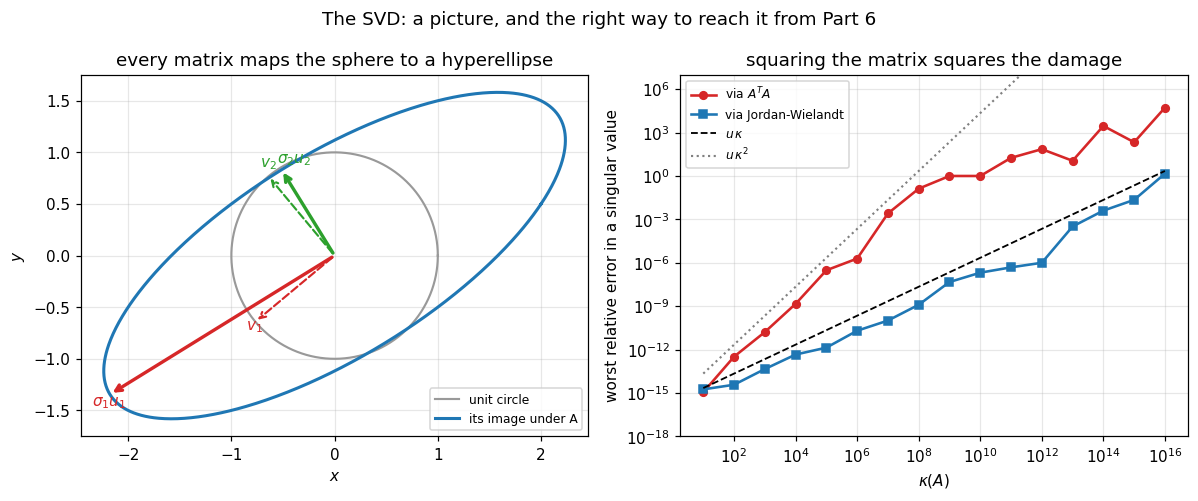

In [12]:
fig, (axL, axR) = plt.subplots(1, 2, figsize=(11, 4.6))

# left: the unit circle and its image, with the axes marked
geo_p = sv.hyperellipse(A_pic, n_points=800)
axL.plot(geo_p["circle"][0], geo_p["circle"][1], "0.6", lw=1.4, label="unit circle")
axL.plot(geo_p["image"][0], geo_p["image"][1], "C0-", lw=2.0, label="its image under A")
for j, colour in ((0, "C3"), (1, "C2")):
    axis = geo_p["semi_axes"][j] * geo_p["axis_directions"][:, j]
    pre = geo_p["preimages"][:, j]
    axL.annotate("", xy=axis, xytext=(0, 0),
                 arrowprops=dict(arrowstyle="->", color=colour, lw=2.2))
    axL.annotate("", xy=pre, xytext=(0, 0),
                 arrowprops=dict(arrowstyle="->", color=colour, lw=1.4, ls="--"))
    axL.text(*(axis * 1.08), f"$\\sigma_{j + 1} u_{j + 1}$", color=colour, fontsize=10)
    axL.text(*(pre * 1.12), f"$v_{j + 1}$", color=colour, fontsize=10)
axL.set_aspect("equal", adjustable="datalim")
axL.set_xlabel("$x$")
axL.set_ylabel("$y$")
axL.set_title("every matrix maps the sphere to a hyperellipse")
axL.legend(fontsize=8, loc="lower right")

# right: the two eigenvalue routes against the condition number
kappas_p, gram_p, jordan_p = [], [], []
for expo in range(1, 17):
    A_r = sv.graded_matrix(40, 8, 10.0 ** expo, rng=np.random.default_rng(3))
    exact_r = np.linalg.svd(A_r, compute_uv=False)
    rel_r = lambda v: float(np.max(np.abs(v - exact_r) / np.maximum(exact_r, 1e-300)))
    kappas_p.append(10.0 ** expo)
    gram_p.append(max(rel_r(sv.singular_values_from_eigen(A_r, "gram")), 1e-17))
    jordan_p.append(max(rel_r(sv.singular_values_from_eigen(A_r, "jordan")), 1e-17))
axR.loglog(kappas_p, gram_p, "C3o-", lw=1.7, ms=5, label=r"via $A^TA$")
axR.loglog(kappas_p, jordan_p, "C0s-", lw=1.7, ms=5, label="via Jordan-Wielandt")
axR.loglog(kappas_p, np.finfo(float).eps * np.array(kappas_p), "k--", lw=1.2,
           label=r"$u\,\kappa$")
axR.loglog(kappas_p, np.finfo(float).eps * np.array(kappas_p) ** 2, "0.5", ls=":", lw=1.4,
           label=r"$u\,\kappa^2$")
axR.set_xlabel(r"$\kappa(A)$")
axR.set_ylabel("worst relative error in a singular value")
axR.set_title("squaring the matrix squares the damage")
axR.legend(fontsize=8)
axR.set_ylim(1e-18, 1e7)

fig.suptitle("The SVD: a picture, and the right way to reach it from Part 6", fontsize=12)
fig.tight_layout()
plt.show()

**The right panel is section 8.** The $A^TA$ curve tracks $u\kappa^2$, the dotted line, and the
Jordan-Wielandt curve tracks $u\kappa$, the dashed one. That is lesson 29's finding, appearing
again in a different part of the subject.

---

## 10. Exercises

**Level 1, conceptual**

1.1 The SVD always exists and an eigendecomposition need not. Give the two conditions the second
one needs, and a matrix failing each.

1.2 Sampling the unit sphere verified the geometric claim at $n = 2$ and failed at $n = 20$.
What went wrong, and does it say anything about the claim?

1.3 Two libraries return different right singular vectors for the same matrix. Give two
circumstances in which both are correct.

**Level 2, mathematical**

2.1 Prove that every matrix has an SVD, by induction on the size, taking $\sigma_1$ as the
maximum of $\|A\mathbf{x}\|$ over the unit sphere and showing the maximiser splits off a block.

2.2 Prove that the singular values are unique, and that the vectors are unique up to sign
exactly when the values are simple.

2.3 Prove all four subspace identities, and hence the rank-nullity theorem.

2.4 Prove $\|A\|_2 = \sigma_1$ and $\kappa_2 = \sigma_1/\sigma_n$ from the definitions, and
extend to $\|A\|_F = \sqrt{\sum\sigma_i^2}$.

2.5 Prove Weyl's inequality for singular values, via the Courant-Fischer minimax
characterisation, and explain why the corresponding eigenvalue statement needs symmetry.

**Level 3, computational**

3.1 Implement the SVD from the **eigenvectors** of the Jordan-Wielandt matrix, recovering $U$
and $V$ from its eigenvectors as well as the values, and check all four SVD properties.

3.2 Implement the **polar decomposition** $A = QP$ with $Q$ orthogonal and $P$ symmetric
positive semidefinite, from the SVD, and show it solves the orthogonal Procrustes problem.

3.3 Implement the **CS decomposition** of a matrix with orthonormal columns split into two row
blocks, and relate its cosines and sines to the principal angles between subspaces of lesson 16.

**Level 4, experimental**

4.1 Measure how well random sampling estimates $\sigma_1$ against the dimension, and fit the
relationship. Compare with the theoretical concentration of measure on the sphere.

4.2 Measure the accuracy of both eigenvalue routes against $\kappa$, fit both exponents, and
confirm one is twice the other.

4.3 Measure the sensitivity of singular **vectors** rather than values, against the gap between
neighbouring singular values, and confirm the Wedin bound.

**Level 5, advanced**

5.1 **Why the SVD is not the eigendecomposition of $A^TA$.** They have the same singular values,
so state precisely what is different, in terms of both accuracy and what the vectors are.

5.2 **Singular vectors are not perfectly conditioned.** The values are; the vectors are not.
State the Wedin perturbation theorem, construct a matrix where a tiny perturbation rotates a
singular vector by 90 degrees, and reconcile this with Weyl.

5.3 **The SVD of a product.** Given the SVDs of $A$ and $B$, what can be said about $AB$?
Investigate, and relate the answer to lesson 31 exercise 5.3 on the QR of a product.

## 11. Key takeaways

- **Every matrix maps the unit sphere to a hyperellipse**, and the SVD names its parts: the
  singular values are the semi-axis lengths, $\mathbf{u}_i$ their directions, $\mathbf{v}_i$
  their preimages.
- **Brute force verifies that at $n = 2$ and fails at $n = 20$**, because a random direction in
  twenty dimensions is nowhere near any particular one. The sampled extremes are always on the
  correct side, which is what makes the failure visible rather than misleading.
- **A wide matrix has minimum stretch zero, not $\sigma_{\min}$**, because its null directions
  collapse and the sphere maps onto the solid ellipsoid.
- **The SVD always exists**, for every shape including $1\times n$, $n\times1$, the zero matrix
  and a Jordan block, with no conditions of any kind. That is the sharpest contrast with Part 6.
- **The singular values are unique; the vectors are not.** They are unique up to sign only when
  the value is simple, and a repeated value has a whole subspace of valid vectors. So comparing
  singular vectors between implementations is only meaningful under conditions worth stating.
- **All four fundamental subspaces are columns of $U$ and $V$**, and the fundamental theorem of
  linear algebra becomes a matter of reading them off. Verified at $10^{-16}$ including the
  rank 0 and full rank cases.
- **$\|A\|_2 = \sigma_1$ and $\kappa_2 = \sigma_1/\sigma_n$**, which pays lesson 15's debt. The
  condition number is the eccentricity of the hyperellipse.
- **Weyl's inequality holds for any two matrices of the same shape**: every singular value moves
  by at most $\|E\|_2$. **No symmetry, no squareness.** That is strictly stronger than lesson
  35's eigenvalue statement, and it is why the SVD is the tool for rank and conditioning.
- **The bound is sharp**, attained by a rank one perturbation along the first singular pair, and
  a random direction misses it by the usual factor of about $\sqrt{n}$.
- **The route through $A^TA$ squares the condition number**, and measured at $\kappa = 10^{10}$
  it loses the smallest singular value entirely, relative error 1.00, while the Jordan-Wielandt
  route keeps seven digits.
- **And reading the Jordan-Wielandt spectrum needs care.** Its eigenvalues are $\pm\sigma_i$, so
  the $k$ largest by **modulus** are the plus and minus pair of the top $k/2$, not the singular
  values. That returned plausible numbers and was a real bug in this module.

## Where this goes next

**Lesson 42** computes the SVD: Golub-Kahan bidiagonalization, the implicit QR sweep on the
bidiagonal matrix, and one-sided Jacobi, all of them arranged so that $A^TA$ is never formed.

**Lesson 43** uses it: Eckart-Young, which lesson 33 already borrowed, low rank approximation,
image compression, and the randomised methods that made the SVD practical at scale.

**Part 7** begins interpolation, and the SVD reappears immediately: lesson 47's Lebesgue
constants and lesson 55's orthogonal polynomials are both conditioning statements about
matrices this lesson can now describe.